In [11]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [12]:
import zipfile
import os

# ZIP file ka path
zip_path = "/content/drive/MyDrive/Soil.zip"

# Drive ke andar extract location
extract_path = "/content/drive/MyDrive/soil_dataset"

# Agar pehle se extract nahi hua hai tabhi unzip kare
if not os.path.exists(extract_path):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print("Dataset Extracted in MyDrive Successfully ✅")
else:
    print("Dataset Already Exists in MyDrive ✅")

Dataset Already Exists in MyDrive ✅


In [13]:
# Class Order Fix + Dataset Load
import tensorflow as tf

# ✅ FIXED CLASS ORDER (Is order ko yaad rakhna)
class_names = [
    "Alluvial",
    "Arid",
    "Black",
    "Clay",
    "Dry",
    "Laterite",
    "Loamy",
    "Peat",
    "Red",
    "Sandy",
    "Sandy_loam",
    "Yellow"
]

# Dataset path (Drive wala)
dataset_path = "/content/drive/MyDrive/soil_dataset/Soil"

img_size = (224, 224)
batch_size = 32

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    dataset_path,
    labels="inferred",
    label_mode="int",
    class_names=class_names,   # ⚠️ FIXED ORDER
    image_size=img_size,
    batch_size=batch_size,
    validation_split=0.2,
    subset="training",
    seed=123
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    dataset_path,
    labels="inferred",
    label_mode="int",
    class_names=class_names,
    image_size=img_size,
    batch_size=batch_size,
    validation_split=0.2,
    subset="validation",
    seed=123
)

print("Dataset Loaded Successfully ✅")
print("Class Order:", class_names)

Found 2050 files belonging to 12 classes.
Using 1640 files for training.
Found 2050 files belonging to 12 classes.
Using 410 files for validation.
Dataset Loaded Successfully ✅
Class Order: ['Alluvial', 'Arid', 'Black', 'Clay', 'Dry', 'Laterite', 'Loamy', 'Peat', 'Red', 'Sandy', 'Sandy_loam', 'Yellow']


In [14]:
# Data Preprocessing (Normalization + Performance Boost)
from tensorflow.keras import layers

# 1️⃣ Normalization Layer
normalization_layer = layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))

# 2️⃣ Performance Optimization
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

print("Preprocessing Applied Successfully ✅")

Preprocessing Applied Successfully ✅


In [15]:
# CNN Model Build & Compile
from tensorflow import keras
from tensorflow.keras import layers

# Model Architecture
model = keras.Sequential([

    layers.Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(12, activation='softmax')   # 12 Soil Classes
])

# Compile Model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 12)             │         1,548 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,170,508 (42.61 MB)

 Trainable params: 11,170,508 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [16]:
# Rolling Checkpoint Setup
import tensorflow as tf
import os
from tensorflow.keras.callbacks import Callback

class RollingCheckpoint(Callback):
    def __init__(self, folder_path, base_filename="cnn_model.h5"):
        super().__init__()
        self.folder_path = folder_path
        self.base_filename = base_filename
        os.makedirs(self.folder_path, exist_ok=True)
        self.last_saved = None

    def on_epoch_end(self, epoch, logs=None):
        # Current epoch file
        current_path = os.path.join(self.folder_path, f"{self.base_filename}_epoch{epoch+1:02d}.h5")
        # Save model
        self.model.save(current_path)
        print(f"Checkpoint saved: {current_path}")

        # Delete previous checkpoint
        if self.last_saved and os.path.exists(self.last_saved):
            os.remove(self.last_saved)
            print(f"Previous checkpoint deleted: {self.last_saved}")

        # Update last_saved
        self.last_saved = current_path

# Usage
checkpoint_dir = "/content/drive/MyDrive/soil_checkpoint"
rolling_cb = RollingCheckpoint(folder_path=checkpoint_dir)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.8443 - loss: 1.1468
Validation Loss: 1.0451
Validation Accuracy: 0.8512


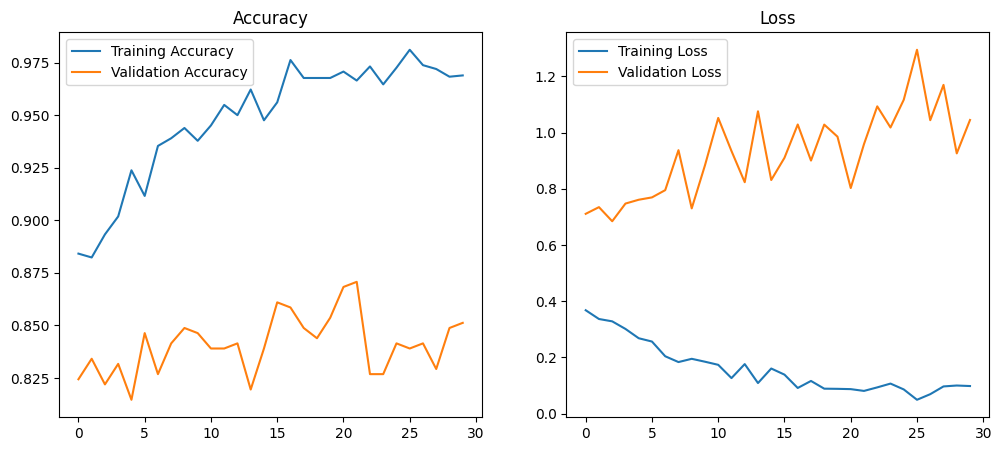

Final Model Saved Successfully at /content/drive/MyDrive/soil_final_model.h5 ✅


In [19]:
# Evaluation + Plot + Save Final Model
import matplotlib.pyplot as plt
from tensorflow import keras
import os

# 1️⃣ Evaluate on Validation Data
val_loss, val_accuracy = model.evaluate(val_ds)
print(f"Validation Loss: {val_loss:.4f}")
print(f"Validation Accuracy: {val_accuracy:.4f}")

# 2️⃣ Plot Accuracy & Loss
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss_list = history.history['val_loss']

epochs_range = range(len(acc))

plt.figure(figsize=(12,5))

# Accuracy Plot
plt.subplot(1,2,1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend()
plt.title('Accuracy')

# Loss Plot
plt.subplot(1,2,2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss_list, label='Validation Loss')
plt.legend()
plt.title('Loss')

plt.show()

# 3️⃣ Save Final Model (.h5)
final_model_path = "/content/drive/MyDrive/soil_final_model.h5"
model.save(final_model_path)
print(f"Final Model Saved Successfully at {final_model_path} ✅")

In [22]:
# Development Script: Load Model + Predict from Image Path or Upload
# ===== Import Libraries =====
from tensorflow import keras
from tensorflow.keras.preprocessing import image
import numpy as np
from google.colab import files
import os

# ===== 1️⃣ Load Trained Model from Drive =====
model_path = "/content/drive/MyDrive/soil_final_model.h5"
model = keras.models.load_model(model_path)
print("Model Loaded Successfully ✅")
model.summary()

# ===== 2️⃣ Class Names (SAME order as training) =====
class_names = [
    "Alluvial", "Arid", "Black", "Clay", "Dry",
    "Laterite", "Loamy", "Peat", "Red", "Sandy",
    "Sandy_loam", "Yellow"
]

# ===== 3️⃣ Function to Predict Soil Type from Image =====
def predict_soil(img_path):
    # Load & Preprocess
    img = image.load_img(img_path, target_size=(224,224))
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    # Predict
    prediction = model.predict(img_array)
    predicted_class = class_names[np.argmax(prediction)]

    print("\nPredicted Soil Type:", predicted_class)
    print("Prediction Confidence:")
    for i, prob in enumerate(prediction[0]):
        print(f"{class_names[i]}: {prob*100:.2f}%")

# ===== 4️⃣ Option: Provide Image Path Directly =====
# Example: img_path = "/content/drive/MyDrive/test_image.jpg"
# predict_soil(img_path)

# ===== 5️⃣ Option: Upload Image from Local Machine =====
uploaded = files.upload()  # Colab widget to upload files
for filename in uploaded.keys():
    img_path = "/content/" + filename
    predict_soil(img_path)

Model Loaded Successfully ✅


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 12)             │         1,548 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,170,510 (42.61 MB)

 Trainable params: 11,170,508 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

Saving sandy loam 3.png to sandy loam 3.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 375ms/step

Predicted Soil Type: Sandy_loam
Prediction Confidence:
Alluvial: 0.06%
Arid: 0.99%
Black: 0.00%
Clay: 0.13%
Dry: 0.00%
Laterite: 0.01%
Loamy: 0.00%
Peat: 0.00%
Red: 0.27%
Sandy: 1.63%
Sandy_loam: 96.91%
Yellow: 0.01%
